Ejercicio 1: NumPy (Procesamiento de Señales con Ruido)
Contexto: Un sensor de temperatura industrial está fallando y genera lecturas erráticas. Necesitas limpiar los datos.

Problema: Crea una función llamada limpiar_sensores que reciba un array bidimensional (2D) de NumPy con las lecturas de los sensores. La función debe:

Identificar cualquier valor atípico extremo menor a -50.0 o mayor a 100.0 y reemplazarlo por el valor np.nan (Not a Number).

Calcular la media de los datos limpios (ignorando los np.nan).

Reemplazar los valores np.nan por esa media calculada.

Devolver el array completamente limpio y la media calculada.

In [6]:
import numpy as np

def limpiar_sensores(matriz_lecturas):
    # 1. Hacemos una copia para no modificar el array original
    matriz_limpia = matriz_lecturas.copy()
    
    # Crea una máscara booleana para identificar los valores fuera de rango
    mascara_error = (matriz_limpia < -50.0) | (matriz_limpia > 100.0)
    
    # Reemplazamos los errores por np.nan usando indexación booleana
    matriz_limpia[mascara_error] = np.nan
    
    # 2. Calculamos la media aritmética ignorando los valores NaN (np.nanmean)
    media_limpia = np.nanmean(matriz_limpia)
    
    # 3. Identificamos dónde quedaron los NaN con np.isnan
    mascara_nan = np.isnan(matriz_limpia)
    
    # Reemplazamos los NaN por el valor de la media calculada
    matriz_limpia[mascara_nan] = media_limpia
    
    return matriz_limpia, media_limpia

# --- VALIDACIÓN CON ASSERT ---
# Matriz de prueba con valores normales, un -99.0 (error) y un 150.0 (error)
datos_sensor = np.array([[20.0, -99.0, 30.0],
                         [10.0, 150.0, 40.0]])

# Los valores válidos son [20, 30, 10, 40]. Su media es 100 / 4 = 25.0
esperado_array = np.array([[20.0, 25.0, 30.0],
                           [10.0, 25.0, 40.0]])
esperada_media = 25.0

resultado_array, resultado_media = limpiar_sensores(datos_sensor)

# Validamos tanto la media como la igualdad de los arrays de NumPy
assert resultado_media == esperada_media
np.testing.assert_array_equal(resultado_array, esperado_array)
print("¡Ejercicio 1 (NumPy) superado con éxito!")

¡Ejercicio 1 (NumPy) superado con éxito!


Ejercicio 2: Pandas (Análisis de Ventas e IVA)
Contexto: Tienes un DataFrame con registros de transacciones comerciales de una tienda. Los montos de venta vienen en formato de texto debido al uso del signo de moneda y comas.

Problema: Crea una función llamada analizar_ventas que reciba este DataFrame y realice lo siguiente:

Limpie la columna Monto, eliminando el signo $ y convirtiendo los datos a tipo numérico (float).

Cree una nueva columna llamada IVA que calcule el 15% del Monto limpio.

Agrupe los datos por la columna Categoria y calcule el monto total de ventas (suma de la columna Monto) por cada categoría.

Devuelva el DataFrame modificado y una Serie de Pandas con los totales por categoría.

In [7]:
import pandas as pd

def analizar_ventas(df_transacciones):
    # Trabajamos sobre una copia para evitar el aviso de 'SettingWithCopyWarning'
    df = df_transacciones.copy()
    
    # 1. Limpiamos el texto eliminando el "$" y convirtiendo a float
    df['Monto'] = df['Monto'].str.replace('$', '', regex=False)
    df['Monto'] = pd.to_numeric(df['Monto'])
    
    # 2. Calculamos el IVA (15% del monto) y lo asignamos a la nueva columna
    df['IVA'] = df['Monto'] * 0.15
    
    # 3. Agrupamos por 'Categoria' y sumamos la columna 'Monto'
    totales_categoria = df.groupby('Categoria')['Monto'].sum()
    
    return df, totales_categoria

# --- VALIDACIÓN CON ASSERT ---
df_prueba = pd.DataFrame({
    'Transaccion': [1, 2, 3, 4],
    'Categoria': ['Electrónica', 'Hogar', 'Electrónica', 'Hogar'],
    'Monto': ['$100.0', '$50.0', '$250.0', '$150.0']
})

df_resultado, serie_totales = analizar_ventas(df_prueba)

# Esperamos que las ventas de Electrónica sumen 350.0 y las de Hogar sumen 200.0
esperado_serie = pd.Series([350.0, 200.0], index=['Electrónica', 'Hogar'], name='Monto')

# Validamos la estructura y los cálculos utilizando .equals() de Pandas
assert serie_totales.equals(esperado_serie)
assert df_resultado['IVA'].iloc[0] == 15.0 # 15% de 100 es 15
print("¡Ejercicio 2 (Pandas) superado con éxito!")

¡Ejercicio 2 (Pandas) superado con éxito!


Ejercicio 3: Matplotlib (Anotación de Puntos Críticos)
Contexto: Quieres graficar el rendimiento de las acciones de una empresa tecnológica a lo largo de una semana y destacar visualmente el día de mayor ganancia.

Problema: Escribe un script utilizando la interfaz orientada a objetos de Matplotlib (fig, ax) para:

Graficar una línea que conecte los días de la semana con el precio de la acción.

Encontrar automáticamente el día con el precio máximo.

Añadir una anotación (texto con flecha) que apunte al punto más alto diciendo "Pico Máximo".

Configurar títulos, etiquetas de ejes y activar la cuadrícula de fondo.

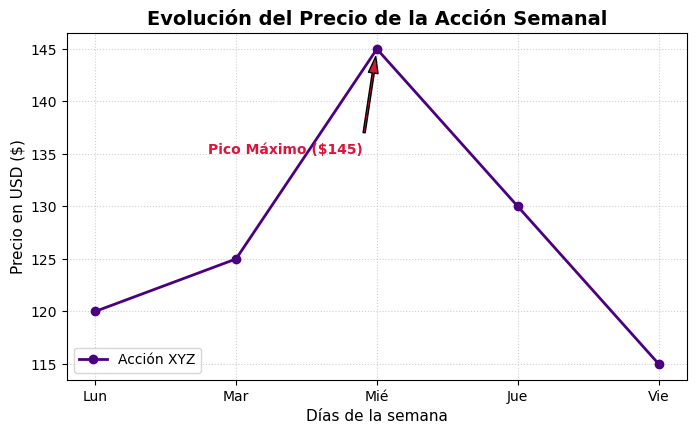

¡Ejercicio 3 (Matplotlib) visualizado con éxito!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de la semana
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie']
precios = [120, 125, 145, 130, 115]

# 1. Creamos los objetos de la estructura del gráfico (Figura y Ejes)
fig, ax = plt.subplots(figsize=(8, 4.5))

# Dibujamos la línea con marcadores circulares y estilo personalizado
ax.plot(dias, precios, marker='o', linestyle='-', color='indigo', linewidth=2, label='Acción XYZ')

# 2. Identificamos el valor máximo y su posición en el eje X de forma programática
precio_maximo = max(precios)
indice_maximo = precios.index(precio_maximo)
dia_maximo = dias[indice_maximo]

# 3. Creamos la anotación con flecha apuntando al precio más alto
ax.annotate(
    text=f'Pico Máximo (${precio_maximo})', # Texto que se mostrará
    xy=(dia_maximo, precio_maximo),         # Coordenada (X, Y) a la que apunta la flecha
    xytext=(indice_maximo - 1.2, precio_maximo - 10), # Coordenada (X, Y) donde se sitúa el texto
    arrowprops=dict(facecolor='crimson', shrink=0.08, width=1.5, headwidth=7), # Estilo de la flecha
    fontweight='bold',
    color='crimson'
)

# 4. Decoradores estéticos del gráfico
ax.set_title('Evolución del Precio de la Acción Semanal', fontsize=14, fontweight='bold')
ax.set_xlabel('Días de la semana', fontsize=11)
ax.set_ylabel('Precio en USD ($)', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6) # Cuadrícula punteada sutil
ax.legend(loc='lower left')

# Mostramos el gráfico finalizado
plt.show()
print("¡Ejercicio 3 (Matplotlib) visualizado con éxito!")

Ejercicio 4: Seaborn (Análisis de Distribuciones Relacionales)
Contexto: Quieres estudiar de manera avanzada cómo influye la potencia de los motores de automóviles en su rendimiento de combustible, segmentado según la región de origen de fabricación.

Problema: Utilizando el dataset interno 'mpg' de Seaborn:

Crea un gráfico de dispersión interactivo con línea de tendencia marginal usando sns.jointplot.

Configura las variables horsepower (eje X) y mpg (eje Y).

Aplica una regresión polinomial de segundo orden (order=2) para que la línea de tendencia se curve adaptándose a la verdadera naturaleza de los datos.

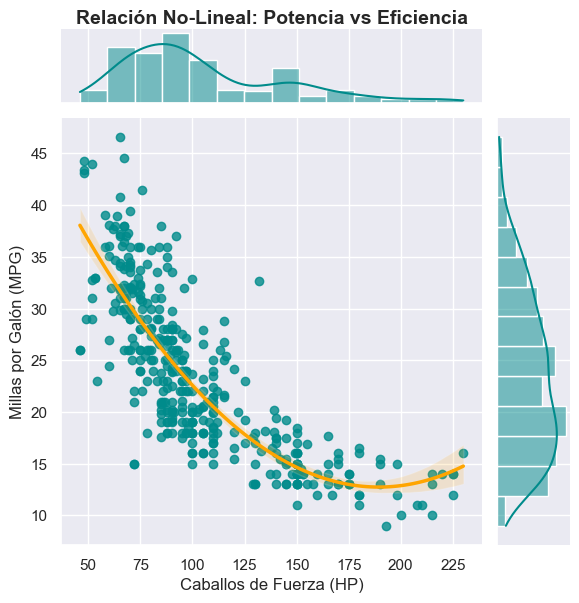

¡Ejercicio 4 (Seaborn) visualizado con éxito!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Activamos el tema estético global de Seaborn para mejorar el diseño
sns.set_theme(style="darkgrid")

# Carga de dataset oficial incorporado en la librería (evitando los comunes iris o tips)
autos_df = sns.load_dataset("mpg")

# Creamos un gráfico relacional combinado (Jointplot)
# kind="reg" añade automáticamente la recta/curva de regresión y los histogramas en los márgenes
grafico_combinado = sns.jointplot(
    data=autos_df, 
    x="horsepower", 
    y="mpg", 
    kind="reg", 
    color="darkcyan",
    # Pasamos argumentos específicos a la función interna de regresión (regplot) mediante un diccionario
    # order=2 calcula un modelo polinomial de segundo grado para ajustarse a los datos curvos
    joint_kws={'order': 2, 'line_kws': {'color': 'orange', 'linewidth': 2.5}}
)

# Ajustamos títulos a los ejes principales mediante la manipulación del objeto Axes interno
grafico_combinado.ax_joint.set_title('Relación No-Lineal: Potencia vs Eficiencia', y=1.2, fontsize=14, fontweight='bold')
grafico_combinado.ax_joint.set_xlabel('Caballos de Fuerza (HP)')
grafico_combinado.ax_joint.set_ylabel('Millas por Galón (MPG)')

plt.show()
print("¡Ejercicio 4 (Seaborn) visualizado con éxito!")